## PREPARACION DE LOS DATOS 

Elegi MNIST porque sus imágenes simples en blanco y negro permiten que la SVD capture directamente la forma geométrica de los números.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

#defino el mnist 
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()[:5000]
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)


## VALORES SINGULARES Y VARIANZA EXPLICADA 

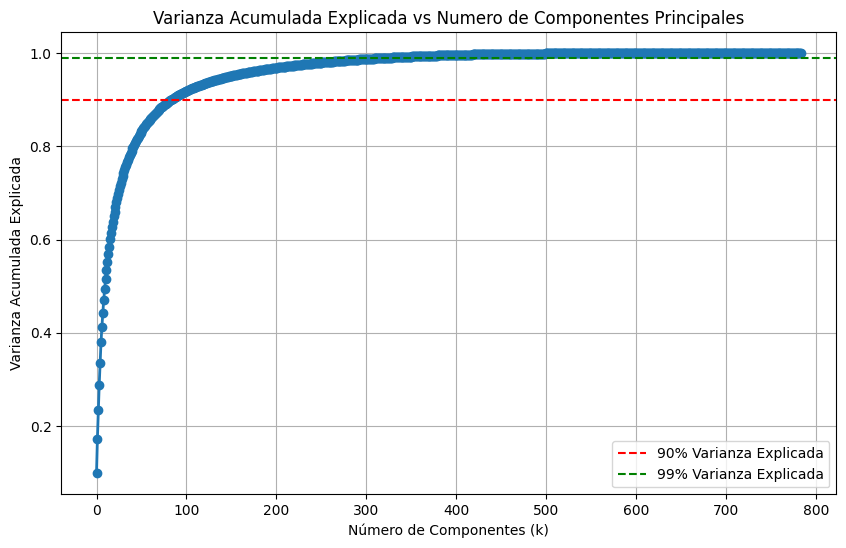

Número de componentes para explicar el 90% de la varianza: 84
Número de componentes para explicar el 99% de la varianza: 322


In [7]:
varianza_explicada = (S**2) / np.sum(S**2)
varianza_acumulada = np.cumsum(varianza_explicada)

#Haciendo el grafico de la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(varianza_acumulada, marker='o', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza Explicada')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Varianza Explicada')
plt.xlabel('Número de Componentes (k)')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Acumulada Explicada vs Numero de Componentes Principales')
plt.legend()
plt.grid(True)
plt.savefig('varianza_acumulada.png')
plt.show()

#Encontramos en que k se supera el 90% y el 99% 
k_90 = np.argmax(varianza_acumulada >= 0.90) + 1
k_99 = np.argmax(varianza_acumulada >= 0.99) + 1
print(f'Número de componentes para explicar el 90% de la varianza: {k_90}')
print(f'Número de componentes para explicar el 99% de la varianza: {k_99}')

<!-- EL grafico muestra una pendiente inicial pronunciada, indicando una alta redundancia espacial en el dataset. Con k = 84 componentes podemos explicar el 90% de la varianza.
Despues de esto la curva se aplana. Los componentes restantes aportan progresivamente menos informacion, asociandose a detalles mas finos. Por esto al alcanzar el 99% de la varianza requiere que k = 322 componentes. -->

## EIGEN-IMAGENES

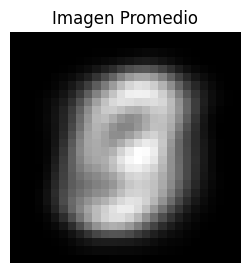

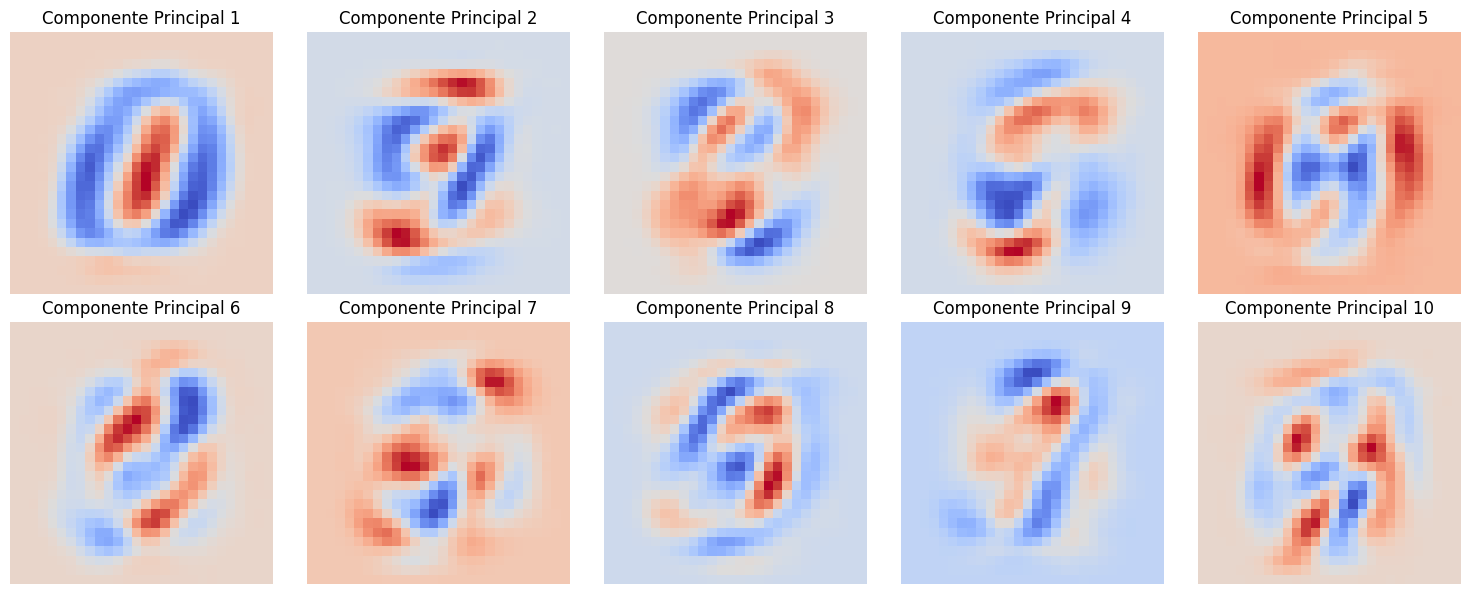

In [8]:
plt.figure(figsize=(3, 3))
plt.imshow(X_mean.reshape(28, 28), cmap='gray')
plt.title("Imagen Promedio")
plt.axis('off')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    eigen_image = Vt[i].reshape(28, 28)
    ax.imshow(eigen_image, cmap='coolwarm')
    ax.set_title(f'Componente Principal {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('componentes_principales.png')
plt.show()

La imagen promedio representa el molde base del dataset, por lo que se puede ver es una imagen parecida a un "0" o un "8" borroso
Eigen_imagen 1 : Captura la principal direccion de variacion respecto al promedio.
Eigen_imagenes 2 y 3: Modelan variaciones geometricas secudarias como la orientacion y distribucion del peso.

## Reconstruccion Progresiva 

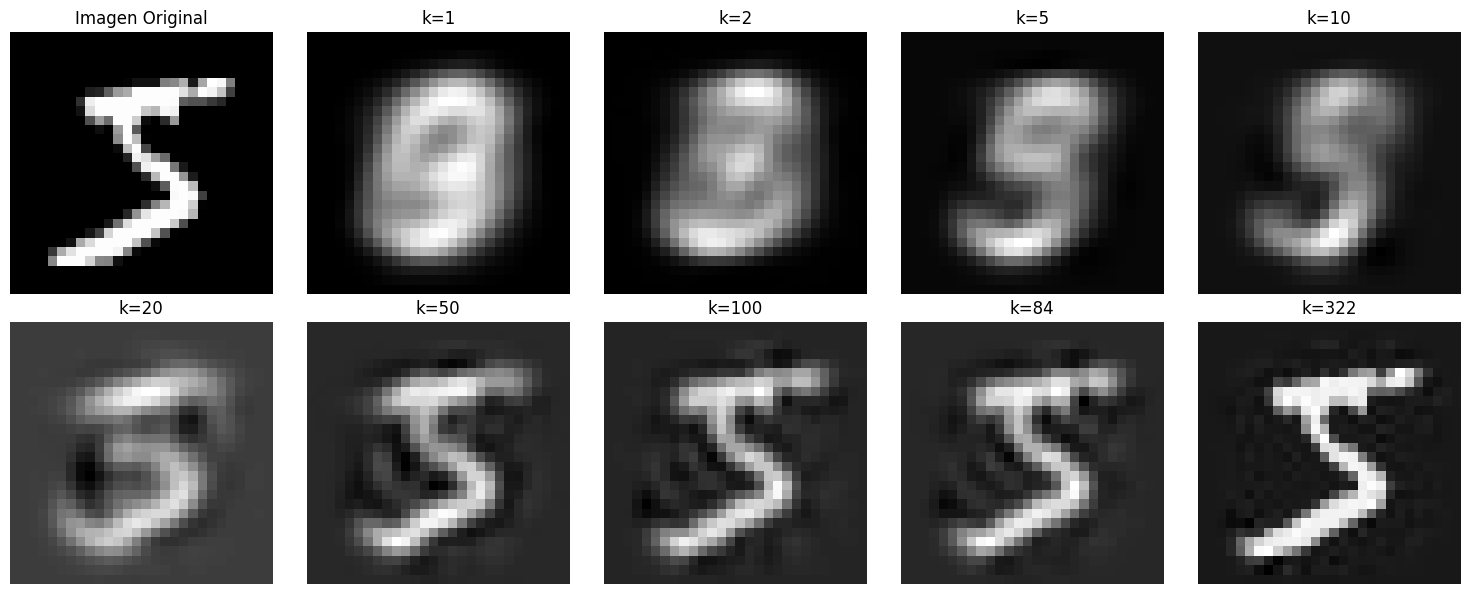

In [9]:
index = 0
x_original = X[index]
x_tilde = X_centered[index]
k_values = [1, 2, 5, 10, 20, 50, 100, k_90, k_99]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

axes[0, 0].imshow(x_original.reshape(28, 28), cmap='gray')
axes[0, 0].set_title("Imagen Original")
axes[0, 0].axis('off')
for i, k in enumerate(k_values):
    ax = axes.flatten()[i+1]
    Vk = Vt[:k, :]
    z = np.dot(x_tilde, Vk.T)
    x_reconstruida = X_mean + np.dot(z, Vk)
    ax.imshow(x_reconstruida.reshape(28, 28), cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('reconstrucciones.png')
plt.show()

Para valores muy bajos k=1 a k=3 la reconstruccion apenas modifica la imagen mostrando la forma mas basica y difusa del numero.
Al alcanzar valores medios como k=10 a k=20 lso contornos principales y el numero ya se puede ir reconociendo mas facilmente.
Y terminando con los otros valores de k la imagen ya va tomando detalles mas finos aproximandose a la imagen original, esto confirma que el error de aproximacion disminuye rapidamente a medida que agregamos los componentes singulares asociados.